In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import numpy as np
import warnings
import geopandas as gpd
from shapely.geometry import Point
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as cfeature
import regionmask
from scipy.interpolate import griddata

#import proplot as pplt

from sklearn.cluster import KMeans

from eofs.multivariate.standard import MultivariateEof
from eofs.xarray import Eof

warnings.filterwarnings("ignore")
from shapely.geometry import box
cl = 'era5_cluster_comp_p_na_DJF1981-2019.nc'
cluster_pcomp = xr.open_mfdataset(cl)
cluster_pcomp

<xarray.Dataset> Size: 28MB
Dimensions:  (cluster: 4, lat: 800, lon: 2200)
Coordinates:
  * lat      (lat) float32 3kB 10.02 10.07 10.12 10.17 ... 49.87 49.92 49.97
  * lon      (lon) float32 9kB 210.0 210.1 210.1 210.2 ... 319.9 319.9 320.0
  * cluster  (cluster) int32 16B 0 1 2 3
Data variables:
    precip   (cluster, lat, lon) float32 28MB dask.array<chunksize=(4, 800, 2200), meta=np.ndarray>

In [4]:
def daily_climo(da,varname,**kwargs):
  
    # This function is adapted the code written by Ray Bell for the SubX project; it is for the
    # verification data
    
    clim_fname = kwargs.get('fname', None)
    
    # Average daily data
    da_day_clim = da.groupby('time.dayofyear').mean('time')
    
    # Rechunk for time
    da_day_clim = da_day_clim.chunk({'dayofyear': 366})
    
    # Pad the daily climatolgy with nans
    x = np.empty((366, len(da_day_clim.lat), len(da_day_clim.lon)))
    x.fill(np.nan)
    _da = xr.DataArray(x,name=varname, coords=[np.linspace(1, 366, num=366, dtype=np.int64),
                              da_day_clim.lat, da_day_clim.lon],
                              dims = da_day_clim.dims)
    da_day_clim_wnan = da_day_clim.combine_first(_da)

    
    # Period rolling twice to make it triangular smoothing
    # See https://bit.ly/2H3o0Mf
    da_day_clim_smooth = da_day_clim_wnan.copy()
 
    

    for i in range(2):
        # Extand the DataArray to allow rolling to do periodic
        da_day_clim_smooth = xr.concat([da_day_clim_smooth[-15:],
                                        da_day_clim_smooth,
                                        da_day_clim_smooth[:15]],
                                        'dayofyear')
        # Rolling mean
        da_day_clim_smooth = da_day_clim_smooth.rolling(dayofyear=31,
                                                        center=True,
                                                        min_periods=1).mean()
        # Drop the periodic boundaries
        da_day_clim_smooth = da_day_clim_smooth.isel(dayofyear=slice(15, -15))

    
    # Extract the original days
    da_day_clim_smooth = da_day_clim_smooth.sel(dayofyear=da_day_clim.dayofyear)

    da_day_clim_smooth.name=varname
    ds_day_clim_smooth=da_day_clim_smooth.to_dataset()
    
    # Save to file if filename provide and return True, otherwise return the data
    if (clim_fname):
        ds_day_clim_smooth.to_netcdf(clim_fname)
        return True
    else:
        return ds_day_clim_smooth

In [5]:
from dask.distributed import Client
from dask.distributed import LocalCluster
cluster = LocalCluster()
cluster

LocalCluster(e3b17357, 'tcp://127.0.0.1:37163', workers=13, threads=26, memory=0.94 TiB)

### Define months, years and NA region as defined by Molina et al., 2023: https://journals.ametsoc.org/view/journals/aies/2/2/AIES-D-22-0051.1.xml

In [6]:
# Region
min_lat = 10
max_lat = 70
#min_lon = 150 #150 E
min_lon = 360-150 #150W
max_lon = 360-40 #40 W

# Date
#sdate = '1979-01-01'
#edate = '2019-12-31'
#sdate = '1999-01-01'
#edate = '2019-12-31'
sdate = '1981-01-01'
edate = '2019-12-31'


# Month
seas='DJF'
seas_mon=[1,2,3,12]
#seas='SONDJFM'
#seas_mon=[9,10,11,12,1,2,3]

npcs = 12

data_path = '/data/esplab/scratch/kpegion/obs_seus/wr_z500/'

In [7]:
inpath = '/data/esplab/shared/reanalysis/era5/daily/z500/'
ifname = 'z.*.nc'
ds_z = xr.open_mfdataset(inpath+ifname,combine='nested',concat_dim='time')
ds_z = ds_z.rename({'latitude':'lat','longitude':'lon'})
ds_z = ds_z.reindex(lat=list(reversed(ds_z['lat'])))
ds_z['z']=ds_z['z']/9.81

In [8]:
ds_z

<xarray.Dataset> Size: 8GB
Dimensions:  (time: 30316, lon: 360, lat: 181)
Coordinates:
  * time     (time) datetime64[ns] 243kB 1940-01-01 1940-01-02 ... 2022-12-31
  * lon      (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat      (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
    level    int32 4B 500
Data variables:
    z        (time, lat, lon) float32 8GB dask.array<chunksize=(366, 181, 360), meta=np.ndarray>
Attributes:
    comments:      Daily data created from: mean of 4xdaily
    source:        Downloaded from Copernicus Data Store: https://cds.climate...
    CreationDate:  2023-07-19
    CreatedBy:     kpegion
    Source:        makeDaily.ipynb

In [9]:
# Make Anoms
ds_climo=daily_climo(ds_z['z'],'z')
ds_anoms=ds_z['z'].groupby('time.dayofyear')-ds_climo

# 5-day running means
ds_zanom=ds_anoms.rolling(time=5,center=True).mean().dropna('time')

# Subset months
ds_zanom = ds_zanom.sel(time=ds_zanom['time.month'].isin(seas_mon))

# Select the dates
ds_zanom=ds_zanom.sel(time=slice(sdate,edate))

In [10]:
ds_zanom

<xarray.Dataset> Size: 2GB
Dimensions:    (lon: 360, lat: 181, time: 4728)
Coordinates:
  * lon        (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat        (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
    level      (time) int32 19kB 500 500 500 500 500 500 ... 500 500 500 500 500
    dayofyear  (time) int64 38kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * time       (time) datetime64[ns] 38kB 1981-01-01 1981-01-02 ... 2019-12-31
Data variables:
    z          (time, lat, lon) float64 2GB dask.array<chunksize=(112, 2, 4), meta=np.ndarray>

In [11]:
# Read in KMEANS clusters
ds_cluster=xr.open_dataset(data_path+'kmeans_4cluster_'+seas+'_1981-2019_NA.nc')

In [12]:
ds_cluster['cluster'].values.min()

0

In [13]:
ds_cluster['cluster'].values.min()

0

In [14]:
print(ds_zanom.dims)
print(ds_cluster.dims)

FrozenMappingWarningOnValuesAccess({'lon': 360, 'lat': 181, 'time': 4728})
FrozenMappingWarningOnValuesAccess({'time': 4728})


In [15]:
# Re-assign the time dimension to contain the cluster assigned to each day
ds_zanom['time']=ds_cluster['cluster']
ds_zanom=ds_zanom.rename({'time':'cluster'})
ds_zanom

<xarray.Dataset> Size: 2GB
Dimensions:    (lon: 360, lat: 181, cluster: 4728)
Coordinates:
  * lon        (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat        (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
    level      (cluster) int32 19kB 500 500 500 500 500 ... 500 500 500 500 500
    dayofyear  (cluster) int64 38kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * cluster    (cluster) int32 19kB 3 3 3 3 3 3 3 3 3 1 ... 2 2 2 2 2 2 1 1 1 1
Data variables:
    z          (cluster, lat, lon) float64 2GB dask.array<chunksize=(112, 2, 4), meta=np.ndarray>

In [5]:
cluster_comp=ds_zanom.groupby('cluster').mean().compute()
cluster_comp

NameError: name 'ds_zanom' is not defined

In [ ]:
cluster_comp.to_netcdf('era5_cluster_comp_z_na_'+seas+'1981-2019.nc')

In [ ]:
#plt.contourf(cluster_comp['z'].sel(cluster=1))
#plt.colorbar()

In [ ]:
cluster4_freq=(ds_zanom.groupby('cluster').count())/len(ds_cluster['time'])
freq=np.round((cluster4_freq['z'][:,0,0].values)*100)

In [ ]:
nrows=2 
ncols=2 
lon_0=260

from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as plt

f, axs = pplt.subplots(nrows=nrows,ncols=2,span=False,proj='npstere',
                       proj_kw={'lon_0': lon_0}, 
                       figsize=(8.5,11.0),
                       sharex=False,sharey=False)

axs.format(abc=True, abcloc='l', abcstyle='(a)')

levs = np.arange(-90,100,10)
cmap = plt.get_cmap('negpos')  # Get the colormap explicitly
norm = BoundaryNorm(levs, cmap.N)  # Create boundary norm

titles=['0: Alaskan Ridge/Pacific Ridge','1: Greenland High',
        '2: Pacific Trough','3: West Coast High']

k=0
for i in np.arange(nrows):
    for j in np.arange(ncols):
        cs1=axs[i,j].contourf(cluster_comp['lon'].values,
                             cluster_comp['lat'].values,
                             cluster_comp['z'][k,:,:].values, 
                             levels=levs,
                             cmap=cmap,
                             norm=norm,
                             extend='both')
        
        axs[i,j].format(title=titles[k]+' ('+str(freq[k])+'%)', 
                       reso='lo', 
                       coastcolor='black', 
                       coast=True, 
                       innerborders=False, 
                       grid=False, 
                       boundinglat=10)
        k=k+1

f.colorbar(cs1,loc='b',length=0.6,label="m")
f.savefig('era5_cluster_comp_z_na_'+seas+'1981-2019.png')

### CHIRPS Precip Data

In [4]:
fname_precip='/data/esplab/shared/obs/gridded/atm/precip/daily/chirps-v2.0/p05/*'
ds_precip=xr.open_mfdataset(fname_precip,combine='by_coords')
ds_precip = ds_precip.rename({'latitude':'lat','longitude':'lon'})
ds_precip=ds_precip.assign_coords(lon=((ds_precip['lon'] + 360) % 360))
ds_precip=ds_precip.sortby(ds_precip['lon'])
ds_precip

<xarray.Dataset> Size: 905GB
Dimensions:  (time: 15705, lat: 2000, lon: 7200)
Coordinates:
  * lat      (lat) float32 8kB -49.97 -49.92 -49.88 -49.82 ... 49.87 49.92 49.97
  * time     (time) datetime64[ns] 126kB 1981-01-01 1981-01-02 ... 2023-12-31
  * lon      (lon) float32 29kB 0.02499 0.07501 0.125 ... 359.9 359.9 360.0
Data variables:
    precip   (time, lat, lon) float32 905GB dask.array<chunksize=(20, 112, 400), meta=np.ndarray>
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2015-11-20
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/chg/products/CH...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

In [5]:
ds_precip_NA=ds_precip.sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon))

NameError: name 'min_lat' is not defined

In [ ]:
ds_precip_NA

In [ ]:
# Make Anoms
ds_pclimo=ds_precip_NA.sel(time=slice(sdate,edate)).groupby('time.dayofyear').mean()
ds_panom=ds_precip_NA.groupby('time.dayofyear')-ds_pclimo

# Select the dates
ds_panom=ds_panom.sel(time=slice(sdate,edate))

ds_panom = ds_panom.sel(time=ds_panom['time.month'].isin(seas_mon))

In [ ]:
ds_panom['time']=ds_cluster['cluster']
ds_panom=ds_panom.rename({'time':'cluster'})
ds_panom

In [ ]:
cluster_pcomp=ds_panom.groupby('cluster').mean().compute()
cluster_pcomp

In [ ]:
cluster_pcomp.to_netcdf('era5_cluster_comp_p_na_'+seas+'1981-2019.nc')
precip

Cluster 0 - Min: -1.0, Max: 1.0
Cluster 0 - Data Shape: (800, 2200)
Cluster 1 - Min: -1.0, Max: 1.0
Cluster 1 - Data Shape: (800, 2200)
Cluster 2 - Min: -1.0, Max: 1.0
Cluster 2 - Data Shape: (800, 2200)
Cluster 3 - Min: -1.0, Max: 1.0
Cluster 3 - Data Shape: (800, 2200)


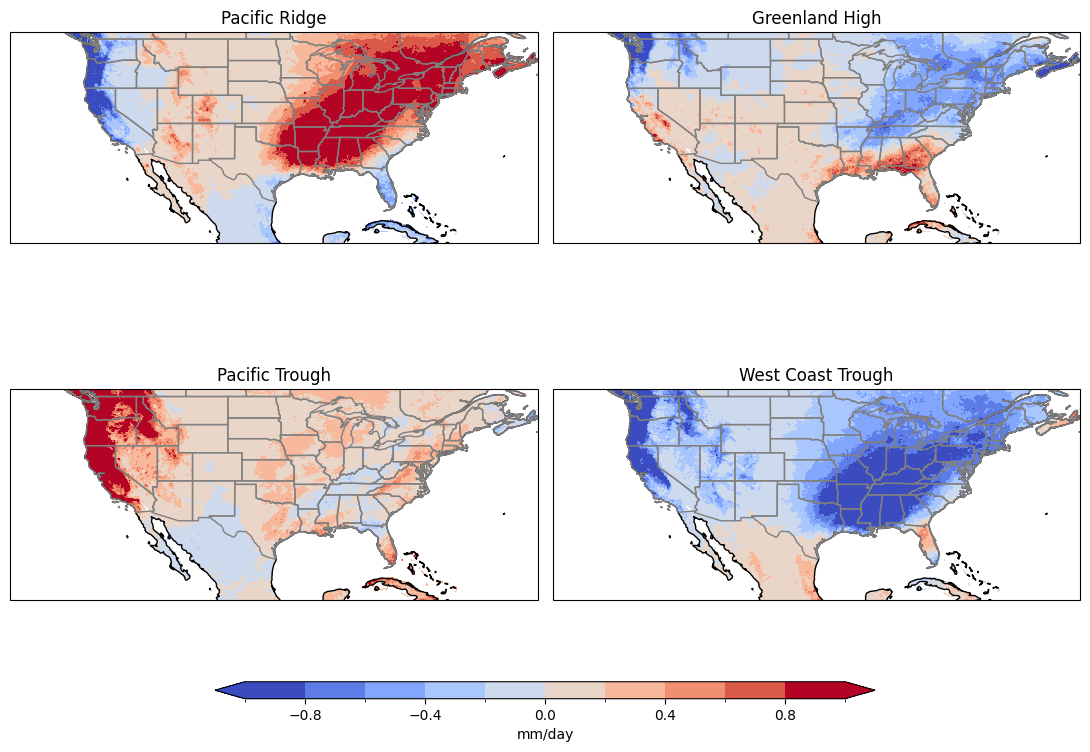

In [2]:
# Load the dataset from the NetCDF file
cluster_pcomp = xr.open_dataset('era5_cluster_comp_p_na_DJF1981-2019.nc')

if 'precip' not in cluster_pcomp:
    raise ValueError("The variable 'precip' does not exist in the dataset. Available variables: ", list(cluster_pcomp.keys()))


nrows = 2
ncols = 2


fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(11.0, 8.5),
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=260)})


axs = axs.flatten()


levs = np.arange(-1, 1.2, 0.2)  


norm = BoundaryNorm(levs, ncolors=256, clip=True)


cmap = plt.get_cmap('coolwarm')  # Replace with 'viridis', 'RdYlBu', or another valid colormap


titles = ['Pacific Ridge', 'Greenland High', 'Pacific Trough', 'West Coast Trough']


for k, ax in enumerate(axs):
    
    precip_data = cluster_pcomp['precip'].isel(cluster=k).load().values  # Load data into memory

   
    if np.isnan(precip_data).all():
        print(f"Cluster {k} - Data is all NaNs. Replacing NaNs with 0 for plotting.")
        precip_data = np.nan_to_num(precip_data, nan=0.0)


    precip_data = np.clip(precip_data, levs.min(), levs.max())

    
    print(f"Cluster {k} - Min: {np.nanmin(precip_data)}, Max: {np.nanmax(precip_data)}")

 
    print(f"Cluster {k} - Data Shape: {precip_data.shape}")

    cs1 = ax.contourf(cluster_pcomp['lon'].values, cluster_pcomp['lat'].values,
                      precip_data, cmap=cmap, extend='both', levels=levs, norm=norm,
                      transform=ccrs.PlateCarree())  # Ensure the transform is set

    ax.set_title(titles[k])

  
    ax.coastlines()


    ax.add_feature(cfeature.STATES, edgecolor='gray')

 
    ax.set_extent([225, 300, 20, 50], crs=ccrs.PlateCarree())

# Add a colorbar below the plots
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(cs1, cax=cbar_ax, orientation='horizontal', label="mm/day")

plt.tight_layout()

plt.savefig('chirps05_cluster_comp_p_na_DJF1981-2019.png')


plt.show()

In [3]:
# Load state shapefile and filter for contiguous US
states = gpd.read_file('cb_2018_us_state_20m.shp')
states = states[~states['NAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

# Define the regimes (clusters) and their names
regimes = {
    0: 'Pacific Ridge',
    1: 'Greenland High',
    2: 'Pacific Trough',
    3: 'West Coast High'
}

# Get the latitude and longitude values from the dataset
lon = cluster_pcomp['lon'].values
lat = cluster_pcomp['lat'].values

# Convert longitude from 0-360 to -180-180
lon = (lon + 180) % 360 - 180

lon_grid, lat_grid = np.meshgrid(lon, lat)


max_valid_lat = 49.975


for cluster, regime_name in regimes.items():
    print(f"\n{regime_name} Precipitation Anomalies by State:")
  
    precip_data = cluster_pcomp['precip'].isel(cluster=cluster).values  # Shape: (lat, lon)
    

    state_precip = {}


    for idx, state in states.iterrows():
        state_name = state['NAME']
        state_geometry = state['geometry']
        
        
        state_geometry = state_geometry.simplify(tolerance=0.01)  
        
        # Bounding box for lat ≤ 49.975°
        valid_lat_box = box(-180, -90, 180, max_valid_lat)
        
        # Clip the state geometry to max at 49.975 degrees to align with precip data
        clipped_geometry = state_geometry.intersection(valid_lat_box)
        
       
        if clipped_geometry.is_empty:
            print(f"{state_name} has no area within the valid latitude range (≤ {max_valid_lat}°). Skipping.")
            continue
        
        # Create a mask 
        state_mask = regionmask.Regions([clipped_geometry]).mask(lon_grid, lat_grid)
        
        # Mask the precipitation data by state
        masked_precip = np.where(state_mask == 0, precip_data, np.nan)  # Apply mask
        
        # Calculate the average precipitation anomaly for each state, filter out nans too
        state_avg_precip = np.nanmean(masked_precip)
        if not np.isnan(state_avg_precip):
            state_precip[state_name] = state_avg_precip
        else:
            print(f"{state_name} has no valid data within the valid latitude range (≤ {max_valid_lat}°).")

 
    for state_name, avg_precip in state_precip.items():
        print(f"{state_name} = {avg_precip:.2f} mm/day")


Pacific Ridge Precipitation Anomalies by State:
Maryland = 0.73 mm/day
Iowa = 0.31 mm/day
Delaware = 0.75 mm/day
Ohio = 1.30 mm/day
Pennsylvania = 1.01 mm/day
Nebraska = 0.06 mm/day
Washington = -0.65 mm/day
Alabama = 0.99 mm/day
Arkansas = 1.57 mm/day
New Mexico = 0.09 mm/day
Texas = 0.15 mm/day
California = -0.77 mm/day
Kentucky = 1.83 mm/day
Georgia = 0.39 mm/day
Wisconsin = 0.41 mm/day
Oregon = -0.70 mm/day
Missouri = 0.96 mm/day
Virginia = 0.59 mm/day
Tennessee = 1.84 mm/day
Louisiana = 0.61 mm/day
New York = 1.00 mm/day
Michigan = 0.73 mm/day
Idaho = -0.00 mm/day
Florida = -0.30 mm/day
Illinois = 1.00 mm/day
Montana = 0.09 mm/day
Minnesota = 0.19 mm/day
Indiana = 1.38 mm/day
Massachusetts = 0.74 mm/day
Kansas = 0.18 mm/day
Nevada = -0.06 mm/day
Vermont = 0.95 mm/day
Connecticut = 0.80 mm/day
New Jersey = 0.79 mm/day
District of Columbia = 0.66 mm/day
North Carolina = 0.34 mm/day
Utah = 0.09 mm/day
North Dakota = 0.04 mm/day
South Carolina = 0.21 mm/day
Mississippi = 1.21 mm/day


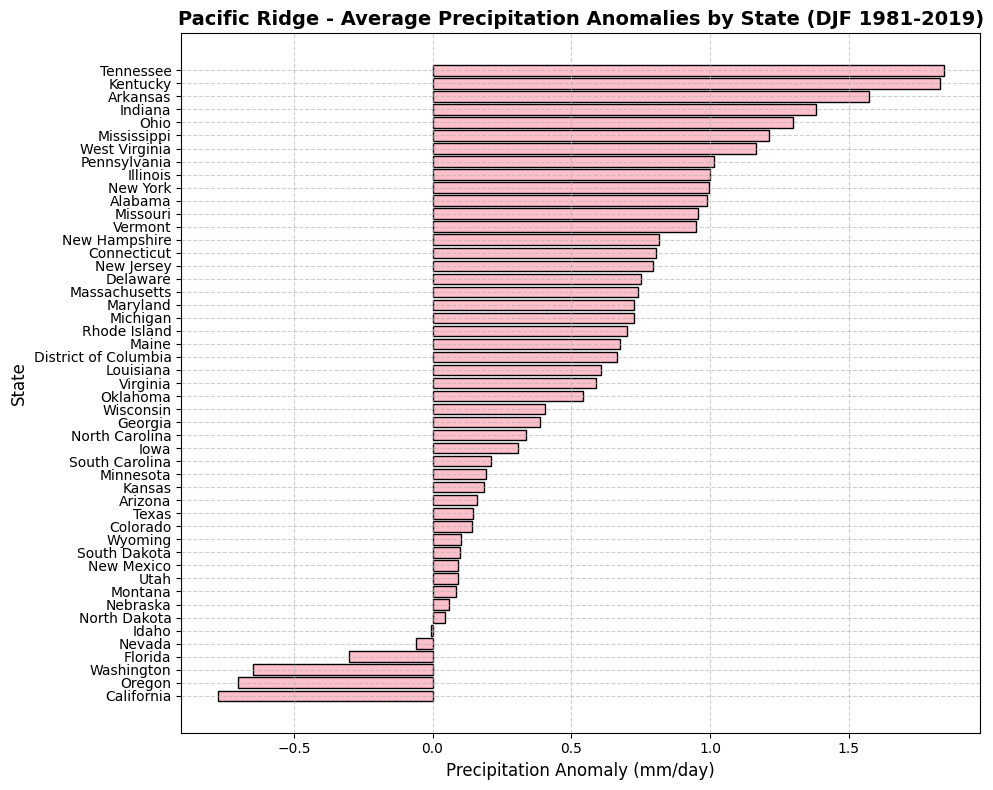

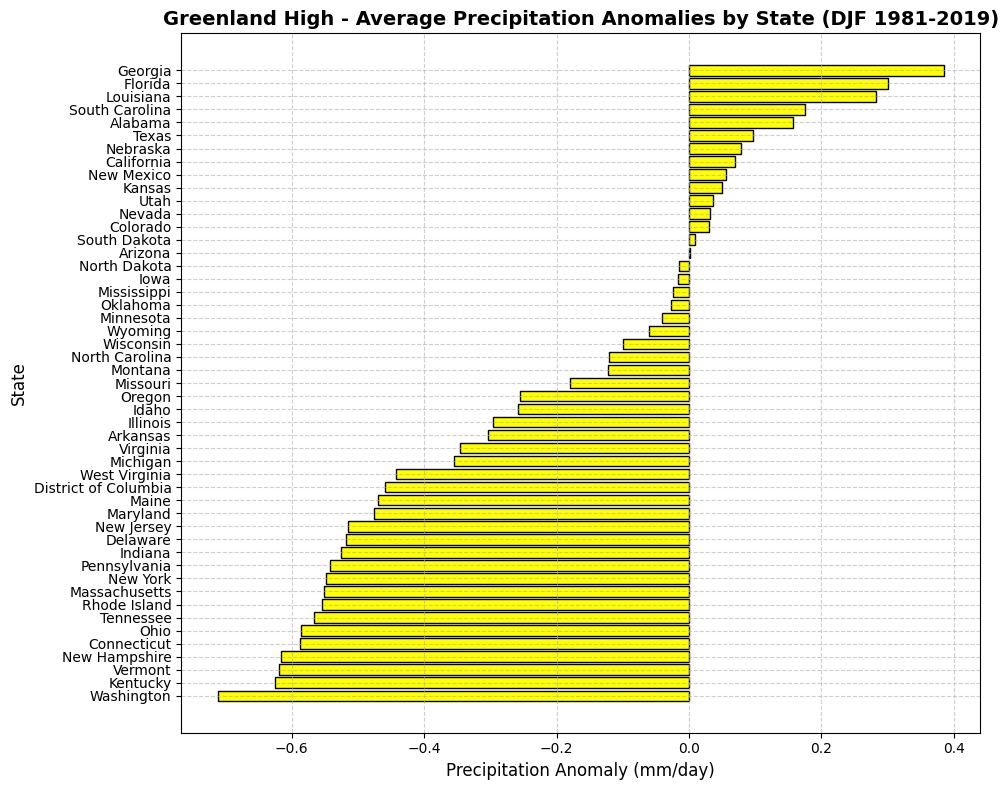

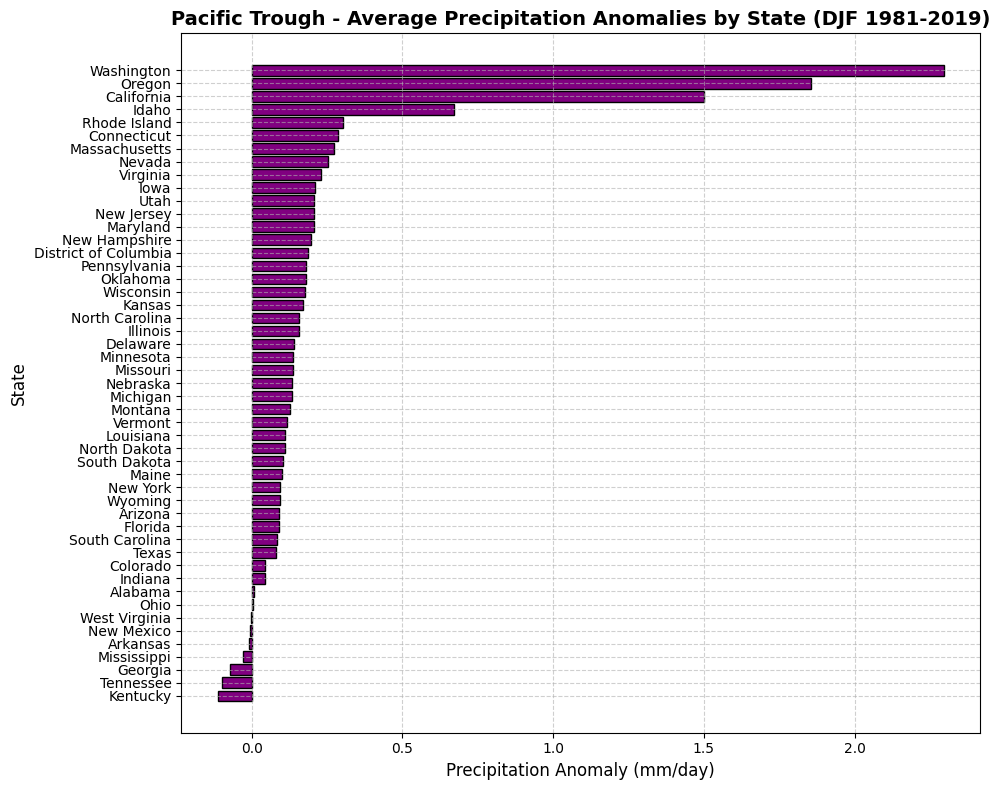

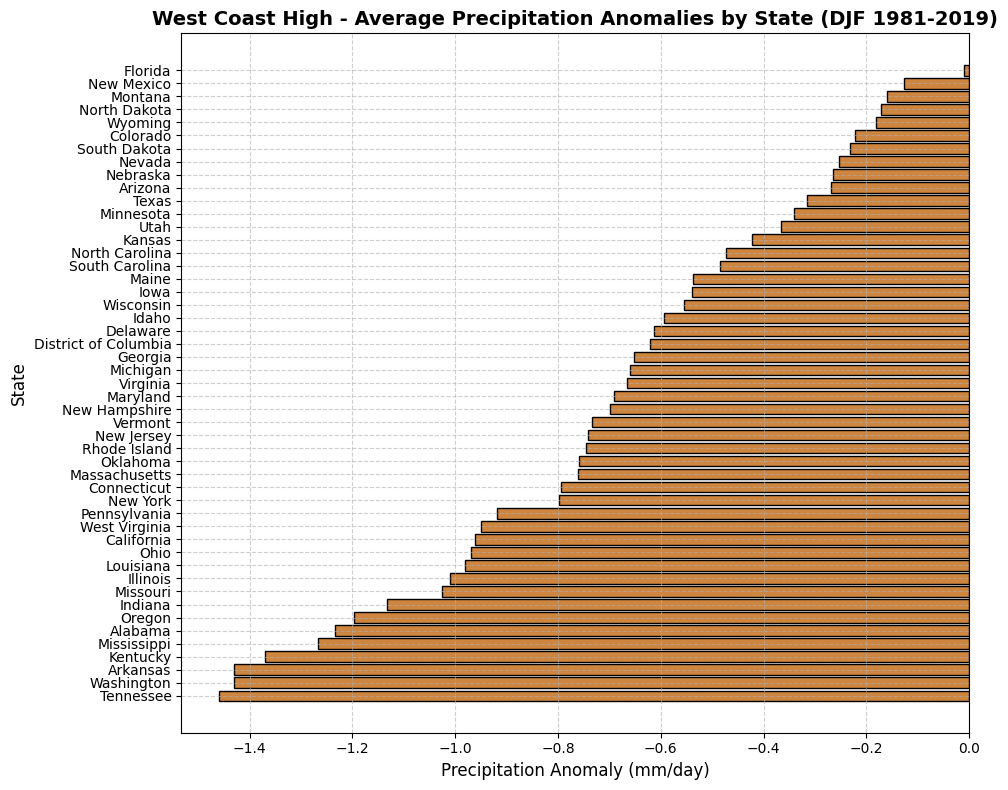

In [4]:

regime_colors = {
    'Pacific Ridge': 'pink',
    'Greenland High': 'yellow',
    'Pacific Trough': 'purple',
    'West Coast High': 'peru'  
}

# Loop through each cluster
for cluster, regime_name in regimes.items():
    # Extract precipitation data per regime
    precip_data = cluster_pcomp['precip'].isel(cluster=cluster).values  # Shape: (lat, lon)
    
    
    state_precip = {}

    # Loop through each state to get avg precip anom
    for idx, state in states.iterrows():
        state_name = state['NAME']
        state_geometry = state['geometry']

        state_geometry = state_geometry.simplify(tolerance=0.01)  # Adjust tolerance as needed
        
        
        valid_lat_box = box(-180, -90, 180, max_valid_lat)
        

        clipped_geometry = state_geometry.intersection(valid_lat_box)
        
       
        if clipped_geometry.is_empty:
            print(f"{state_name} has no area within the valid latitude range (≤ {max_valid_lat}°). Skipping.")
            continue
        
        
        state_mask = regionmask.Regions([clipped_geometry]).mask(lon_grid, lat_grid)
        
     
        masked_precip = np.where(state_mask == 0, precip_data, np.nan)  # Apply mask
        
 
        state_avg_precip = np.nanmean(masked_precip)
        
        if not np.isnan(state_avg_precip):
            state_precip[state_name] = state_avg_precip
        else:
            print(f"{state_name} has no valid data within the valid latitude range (≤ {max_valid_lat}°).")

    # Sort states by precipitation anomaly (greatest to smallest)
    sorted_states = sorted(state_precip.items(), key=lambda x: x[1], reverse=True)
    state_names = [x[0] for x in sorted_states]
    precip_values = [x[1] for x in sorted_states]
    
    # Create the bar plot
    plt.figure(figsize=(10, 8))
    plt.barh(state_names, precip_values, color=regime_colors[regime_name], edgecolor='black')
    plt.xlabel('Precipitation Anomaly (mm/day)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title(f'{regime_name} - Average Precipitation Anomalies by State (DJF 1981-2019)', fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)  # Add gridlines
    plt.gca().invert_yaxis()  # Invert y-axis to show greatest at the top
    plt.tight_layout()
    plt.show()

# Define colors and style
cmap = {'Drought': 'red', 'Flood Risk': 'blue'}
sns.set_style('whitegrid')

for cluster in state_anomalies.index:
    # Sort data and assign labels
    data = state_anomalies.loc[cluster].sort_values(ascending=True)
    labels = [f'{name} ({val:.2f} mm/day)' for name, val in data.items()]
    colors = [cmap['Drought'] if val < 0 else cmap['Flood Risk'] for val in data]

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 16))
    bars = ax.barh(labels, data, color=colors, edgecolor='k')
    
    # Add labels/title
    ax.set_title(f'Cluster {cluster}: Precipitation Anomalies ({seas} 1981-2019)', fontsize=14)
    ax.set_xlabel('Precipitation Anomaly (mm/day)', fontsize=12)
    ax.axvline(0, color='black', linestyle='--')
    
    # Adjust layout
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10, rotation=0)
    plt.tight_layout()
    
    # Save and close
    plt.savefig(f'cluster_{cluster}_precip_anomalies.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:


    # Loop through each state and calculate the average precipitation anomaly
    for idx, state in states.iterrows():
        state_name = state['NAME']
        state_geometry = state['geometry']
        
        # Handle MultiPolygon geometries
        if state_geometry.geom_type == 'MultiPolygon':
            # Create a combined mask for all polygons in the MultiPolygon
            state_mask = None
            for polygon in state_geometry.geoms:
                polygon_mask = regionmask.Regions([polygon]).mask(lon, lat)
                if state_mask is None:
                    state_mask = polygon_mask
                else:
                    state_mask = np.logical_or(state_mask, polygon_mask)
        else:
            # Handle single Polygon geometries
            state_mask = regionmask.Regions([state_geometry]).mask(lon, lat)
        
        # Mask the precipitation data for the current state
        masked_precip = np.where(state_mask == 0, precip_data, np.nan)  # Apply mask
        
        # Calculate the average precipitation anomaly for the state, ignoring NaNs
        state_avg_precip = np.nanmean(masked_precip)
        
        # Store the result (only if the average is not NaN)
        if not np.isnan(state_avg_precip):
            state_precip[state_name] = state_avg_precip
        else:
            print(f"{state_name} has no valid data within the precipitation grid.")

    # Print the results for the current regime
    for state_name, avg_precip in state_precip.items():
        print(f"{state_name} = {avg_precip:.2f} mm/day")

'Rhode Island'

### CPC Precip Data

In [ ]:
fname_precip='/data/esplab/shared/obs/gridded/atm/precip/daily/CPC-UNI-GLOBAL/precip.*.nc'
ds_precip_cpc=xr.open_mfdataset(fname_precip,combine='by_coords')
ds_precip_cpc=ds_precip_cpc.reindex(lat=list(reversed(ds_precip_cpc['lat'])))

In [ ]:
ds_precip_cpc

In [ ]:
ds_precip_NA=ds_precip_cpc.sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon))

In [ ]:
# Make Anoms
ds_pclimo_cpc=ds_precip_NA.sel(time=slice(sdate,edate)).groupby('time.dayofyear').mean()
ds_panom_cpc=ds_precip_NA.groupby('time.dayofyear')-ds_pclimo_cpc
ds_panom_cpc

In [ ]:
ds_panom_cpc=ds_panom_cpc.sel(time=slice(sdate,edate))
ds_panom_cpc = ds_panom_cpc.sel(time=ds_panom_cpc['time.month'].isin(seas_mon))
ds_panom_cpc

In [ ]:
ds_cluster

In [ ]:
ds_panom_cpc['time']=ds_cluster['cluster']
ds_panom_cpc=ds_panom_cpc.rename({'time':'cluster'})
ds_panom_cpc

In [ ]:
cluster_pcomp_cpc=ds_panom_cpc.groupby('cluster').mean().compute()
cluster_pcomp_cpc

In [ ]:
nrows=2
ncols=2
lon_0=260
f, axs = pplt.subplots(nrows=nrows,ncols=2,span=False,proj='pcarree',proj_kw={'lon_0': lon_0},
                           figsize=(11.0,8.5),sharex=False,sharey=False)
axs.format(abc=True, abcloc='l', abcstyle='(a)')
levs=np.arange(-1,1.2,0.2)
cmap='DryWet'
k=0
for i in np.arange(nrows):
    for j in np.arange(ncols):

        # Make a filled contour plot
        cs1=axs[i,j].contourf(cluster_pcomp_cpc['lon'].values,cluster_pcomp_cpc['lat'].values,cluster_pcomp_cpc['precip'][k,:,:].values,
                        cmap=cmap,extend='both',levels=levs,
                        labels_kw={'fontsize': 'large'})
        
        axs[i,j].format(title=titles[k],
                  reso='lo', coastcolor='black',suptitle='CPC-UNI Global Precip Anomalies by Weather Regime (mm/day)',
                  coast=True, innerborders=False, grid=False, lonlim=(225,300), latlim=(20,50))
        axs[i,j].add_feature(cfeature.STATES,edgecolor='gray') 

        k=k+1
        
f.colorbar(cs1,loc='b',length=0.6,label="") 
f.savefig('cpcuniglobal_cluster_comp_p_na_'+seas+'1981-2019.png')